# Predicción de Demanda y Quiebre de Stock en Retail
**Realizado por:** Daniela Auquilla, José Salamea, Pedro Gonzalez y Carlos Moyano
**Fecha:** Julio 2026
**Dataset:** Store Item Demand Forecasting Challenge (Kaggle) — subconjunto de 1 tienda y 10 productos
**Materia:** Inteligencia Artificial
**Prototipo:** V2 — Pipeline final (modelo seleccionado: XGBoost)

## Introducción


¿Alguna vez ha ido a comprar un artículo específico a la tienda y se ha encontrado con que se había agotado? Para los clientes esto resulta insatisfactorio y para la tienda representa una pérdida de ingresos. En el sector comercial, esto se conoce como **quiebre de stock** o desabastecimiento.

En este proyecto, se resuelve este problema utilizando **Inteligencia Artificial aplicada a Series de Tiempo**. El pipeline analiza el historial de ventas pasadas como si fuera un registro detallado del comportamiento de los clientes, y utiliza esa información para estimar con precisión cuánto se venderá en las próximas semanas. De este modo, la tienda puede abastecerse de manera oportuna.

## Índice

1. Configuración del pipeline
2. Carga y preparación de datos
   - 2.1 Carga y filtrado
   - 2.2 Revisión y limpieza de datos
3. Análisis exploratorio (EDA)
   - 3.1 Estacionalidad anual (ventas por mes)
   - 3.2 Estacionalidad semanal (ventas por día)
4. Ingeniería de variables (Feature Engineering)
   - 4.1 Variables de calendario
   - 4.2 Categoría de rotación del producto
   - 4.3 Variables de historial (lags y ventanas móviles)
5. División temporal de los datos (Train / Test)
6. Modelado (XGBoost)
   - 6.1 Entrenamiento y evaluación
   - 6.2 Importancia de variables
   - 6.3 Predicción vs. realidad
7. Función de predicción (demanda estimada)
   - 7.1 Motor de predicción (uso interno)
   - 7.2 Validación de la predicción recursiva
   - 7.3 `cuanto_comprar` — un producto específico
   - 7.4 `plan_de_compras` — todo el catálogo
8. De demanda estimada a cantidad a pedir (incorporando stock)
   - 8.1 Carga del archivo de stock
   - 8.2 `cuanto_pedir` — un producto específico
   - 8.3 `plan_de_pedidos` — todo el catálogo
9. Conclusiones


## 1. Configuración del pipeline

Todos los parámetros que cambiarían al usar este notebook con otro dataset o con datos reales de una empresa se concentran aquí. Para adaptar el pipeline a un nuevo caso, en principio solo es necesario ajustar esta celda.

- **Columnas:** nombres tal como aparecen en el archivo de origen. `COLUMNA_TIENDA` puede dejarse en `None` si el dataset no distingue por sucursal.
- **Alcance:** qué tienda y qué productos se usan en este prototipo (`None` para usar todos los disponibles).
- **`PORCENTAJE_TEST`:** en lugar de fijar una cantidad de meses, se reserva un porcentaje del historial total como conjunto de prueba. Esto hace que el tamaño del test se ajuste automáticamente sin importar si el historial disponible son 8 meses o 5 años.
- **`LAGS` / `VENTANAS_ROLLING`:** ventanas de historial (en días) usadas para construir las variables predictoras.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# ==================== CONFIGURACIÓN (ajustar según el dataset/cliente) ====================
RUTA_DATOS = 'data/train.csv'
COLUMNA_FECHA = 'date'
COLUMNA_PRODUCTO = 'item'
COLUMNA_TIENDA = 'store'        # usar None si el dataset no tiene columna de tienda
COLUMNA_VENTAS = 'sales'

TIENDA_A_USAR = 1               # usar None si no aplica / no hay columna de tienda
PRODUCTOS_A_USAR = [15, 28, 22, 8, 12, 24, 9, 20, 3, 5]   # usar None para tomar todos los disponibles

PORCENTAJE_TEST = 0.05          # proporción del historial total reservada para evaluación
LAGS = [7, 14, 30]              # días de historial para las variables de lag
VENTANAS_ROLLING = [7, 30]      # días de historial para promedios móviles

# ---- Configuración del archivo de STOCK (sección 8) ----
RUTA_STOCK = 'data/stock_actual.csv'
COLUMNA_STOCK_PRODUCTO = 'codigo_producto'
COLUMNA_STOCK_CANTIDAD = 'stock_actual'
COLUMNA_STOCK_FECHA = 'fecha_corte'
# ============================================================================================

print("Configuración cargada correctamente.")


Configuración cargada correctamente.


## 2. Carga y preparación de datos

### 2.1 Carga y filtrado

Se carga el archivo de origen y se renombran las columnas a nombres internos estándar (`date`, `item`, `store`, `sales`), de modo que el resto del pipeline no dependa de cómo se llamen las columnas en el archivo original. Luego se filtra según la tienda y los productos definidos en la configuración.


In [2]:
df_raw = pd.read_csv(RUTA_DATOS, parse_dates=[COLUMNA_FECHA])

renombres = {COLUMNA_FECHA: 'date', COLUMNA_PRODUCTO: 'item', COLUMNA_VENTAS: 'sales'}
if COLUMNA_TIENDA is not None:
    renombres[COLUMNA_TIENDA] = 'store'
df_raw = df_raw.rename(columns=renombres)

print("Dataset original:")
info = f"  Filas: {len(df_raw)} | Productos: {df_raw['item'].nunique()}"
if 'store' in df_raw.columns:
    info += f" | Tiendas: {df_raw['store'].nunique()}"
print(info)
print(f"  Rango de fechas: {df_raw['date'].min().date()} a {df_raw['date'].max().date()}")

df = df_raw.copy()
if 'store' in df.columns and TIENDA_A_USAR is not None:
    df = df[df['store'] == TIENDA_A_USAR]
if PRODUCTOS_A_USAR is not None:
    df = df[df['item'].isin(PRODUCTOS_A_USAR)]

df = df.sort_values(['item', 'date']).reset_index(drop=True)

print(f"\nSubconjunto usado en este prototipo:")
print(f"  Filas: {len(df)} | Productos: {df['item'].nunique()} de {df_raw['item'].nunique()} disponibles")
df.head()


Dataset original:
  Filas: 913000 | Productos: 50 | Tiendas: 10
  Rango de fechas: 2013-01-01 a 2017-12-31

Subconjunto usado en este prototipo:
  Filas: 18260 | Productos: 10 de 50 disponibles


,date,store,item,sales
0,2013-01-01,1,3,15
1,2013-01-02,1,3,30
2,2013-01-03,1,3,14
3,2013-01-04,1,3,10
4,2013-01-05,1,3,23


### 2.2 Revisión y limpieza de datos

Se verifica que no existan valores nulos, filas duplicadas (misma fecha y producto), ni días faltantes en el historial de cada producto.


In [3]:
print("Valores nulos por columna:")
print(df[['date','item','sales']].isnull().sum())

duplicados = df.duplicated(subset=['date','item']).sum()
print(f"\nFilas duplicadas (fecha + producto): {duplicados}")

dias_esperados = (df['date'].max() - df['date'].min()).days + 1
conteo_por_producto = df.groupby('item')['date'].count()
faltantes = conteo_por_producto[conteo_por_producto != dias_esperados]

if faltantes.empty:
    print(f"\n Todos los productos tienen los {dias_esperados} días completos, sin fechas faltantes.")
else:
    print("\n Productos con fechas faltantes:")
    print(faltantes)


Valores nulos por columna:
date     0
item     0
sales    0
dtype: int64

Filas duplicadas (fecha + producto): 0

 Todos los productos tienen los 1826 días completos, sin fechas faltantes.


## 3. Análisis exploratorio (EDA)

### 3.1 Estacionalidad anual

Se agregan las ventas totales por mes (en vez de por día) para observar tendencia y estacionalidad sin el ruido propio de los datos diarios.


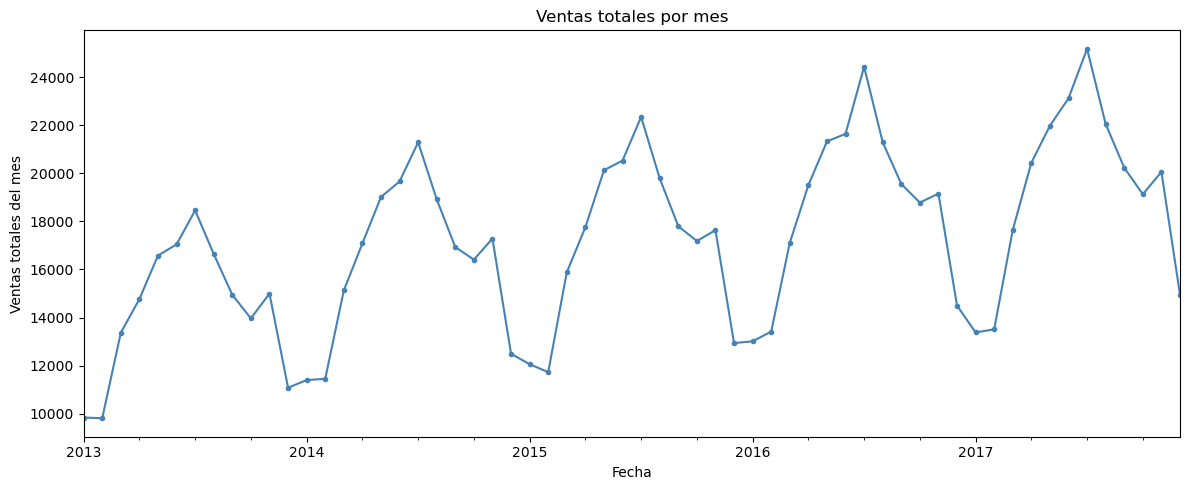

In [4]:
serie_mensual = df.set_index('date').groupby(pd.Grouper(freq='ME'))['sales'].sum()

plt.figure(figsize=(12, 5))
serie_mensual.plot(color='steelblue', marker='o', markersize=3)
plt.title('Ventas totales por mes')
plt.ylabel('Ventas totales del mes')
plt.xlabel('Fecha')
plt.tight_layout()
plt.show()


**Lectura del gráfico:** se observa un patrón que se repite cada año, con ventas altas hacia mitad de año y una caída hacia noviembre-diciembre, lo que confirma estacionalidad anual. Adicionalmente, el nivel general de ventas mensuales aumenta año tras año, evidenciando una tendencia de crecimiento sostenido.

### 3.2 Estacionalidad semanal

Se calcula el promedio de ventas agrupando todas las filas según el día de la semana al que corresponden (combinando todos los productos y todos los años del historial).


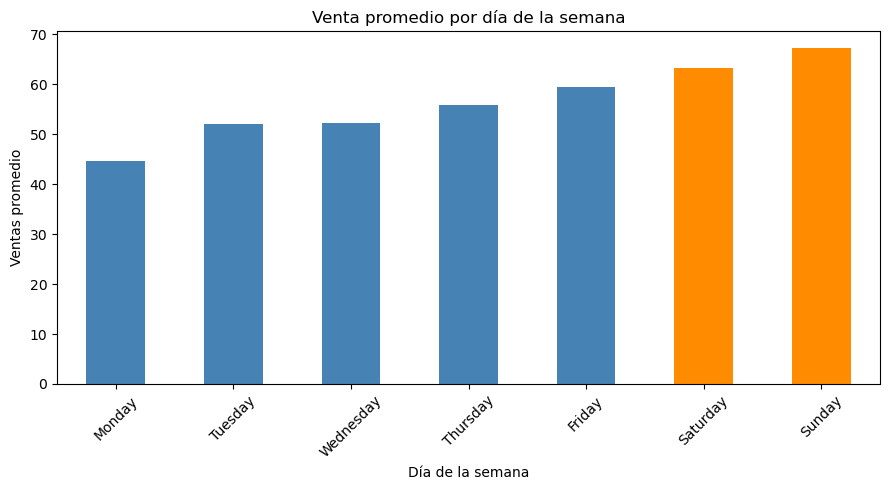

In [5]:
df['dia_semana'] = df['date'].dt.day_name()
orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
promedio_por_dia = df.groupby('dia_semana')['sales'].mean().reindex(orden_dias)

colores = ['steelblue']*5 + ['darkorange']*2  # Lunes-Viernes vs Sábado-Domingo

plt.figure(figsize=(9, 5))
promedio_por_dia.plot(kind='bar', color=colores)
plt.title('Venta promedio por día de la semana')
plt.ylabel('Ventas promedio')
plt.xlabel('Día de la semana')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Lectura del gráfico:** las ventas promedio aumentan progresivamente a lo largo de la semana, siendo sábado y domingo (resaltados en naranja) los días de mayor demanda. Esto confirma un patrón semanal relevante que se incorpora como variable de calendario en la siguiente sección.


## 4. Ingeniería de variables (Feature Engineering)

### 4.1 Variables de calendario

Directamente justificadas por el EDA: se construyen variables que permiten al modelo capturar la estacionalidad semanal y anual observada.


In [6]:
df_feat = df.copy()

df_feat['dia_semana_num'] = df_feat['date'].dt.dayofweek     # 0=Lunes, 6=Domingo
df_feat['dia_mes'] = df_feat['date'].dt.day
df_feat['mes'] = df_feat['date'].dt.month
df_feat['trimestre'] = df_feat['date'].dt.quarter
df_feat['anio'] = df_feat['date'].dt.year
df_feat['es_fin_de_semana'] = df_feat['dia_semana_num'].isin([5, 6]).astype(int)

df_feat[['date','item','sales','dia_semana_num','mes','trimestre','anio','es_fin_de_semana']].head()


,date,item,sales,dia_semana_num,mes,trimestre,anio,es_fin_de_semana
0,2013-01-01,3,15,1,1,1,2013,0
1,2013-01-02,3,30,2,1,1,2013,0
2,2013-01-03,3,14,3,1,1,2013,0
3,2013-01-04,3,10,4,1,1,2013,0
4,2013-01-05,3,23,5,1,1,2013,1


### 4.2 Categoría de rotación del producto

En lugar de usar el identificador del producto (`item`) directamente —lo que llevaría al modelo a memorizar comportamientos ligados a un número específico, sin capacidad de generalizar a productos nuevos—, se calcula una categoría de rotación (alta/media/baja) mediante **terciles** (`pd.qcut`), calculados automáticamente sobre la distribución real de los datos. Esto hace que la categorización se adapte a la escala de cualquier dataset, sin depender de umbrales fijos.


In [7]:
promedio_por_producto = df_feat.groupby('item')['sales'].mean()
categorias = pd.qcut(promedio_por_producto, q=3, labels=['baja', 'media', 'alta'])

tabla_rotacion = pd.DataFrame({
    'item': promedio_por_producto.index,
    'promedio_ventas': promedio_por_producto.values.round(1),
    'categoria_rotacion': categorias.values
}).sort_values('promedio_ventas', ascending=False).reset_index(drop=True)

tabla_rotacion


,item,promedio_ventas,categoria_rotacion
0,15,79.7,alta
1,28,79.6,alta
2,22,72.8,alta
3,8,69.5,alta
4,12,63.2,media
5,24,60.0,media
6,9,46.5,baja
7,20,42.9,baja
8,3,33.2,baja
9,5,16.6,baja


In [8]:
mapa_rotacion = tabla_rotacion.set_index('item')['categoria_rotacion'].to_dict()
df_feat['categoria_rotacion'] = df_feat['item'].map(mapa_rotacion)
df_feat = pd.get_dummies(df_feat, columns=['categoria_rotacion'], prefix='rotacion')

columnas_rotacion = [c for c in df_feat.columns if c.startswith('rotacion_')]
print("Columnas de rotación creadas:", columnas_rotacion)
df_feat.head()


Columnas de rotación creadas: ['rotacion_alta', 'rotacion_baja', 'rotacion_media']


,date,store,item,sales,dia_semana,dia_semana_num,dia_mes,mes,trimestre,anio,es_fin_de_semana,rotacion_alta,rotacion_baja,rotacion_media
0,2013-01-01,1,3,15,Tuesday,1,1,1,1,2013,0,False,True,False
1,2013-01-02,1,3,30,Wednesday,2,2,1,1,2013,0,False,True,False
2,2013-01-03,1,3,14,Thursday,3,3,1,1,2013,0,False,True,False
3,2013-01-04,1,3,10,Friday,4,4,1,1,2013,0,False,True,False
4,2013-01-05,1,3,23,Saturday,5,5,1,1,2013,1,False,True,False


### 4.3 Variables de historial (lags y ventanas móviles)

Se construyen, **por producto** (para no mezclar el historial de uno con el de otro), variables de venta pasada (lags) y promedios/variabilidad de los últimos días (ventanas móviles). Estas son, según la experimentación previa, las variables más influyentes del modelo.


In [9]:
df_feat = df_feat.sort_values(['item', 'date']).reset_index(drop=True)

for lag in LAGS:
    df_feat[f'lag_{lag}'] = df_feat.groupby('item')['sales'].shift(lag)

for w in VENTANAS_ROLLING:
    df_feat[f'media_movil_{w}'] = df_feat.groupby('item')['sales'].transform(lambda x: x.rolling(w).mean())

df_feat[f'std_movil_{VENTANAS_ROLLING[0]}'] = df_feat.groupby('item')['sales'].transform(
    lambda x: x.rolling(VENTANAS_ROLLING[0]).std()
)

columnas_lag = [f'lag_{l}' for l in LAGS]
columnas_rolling = [f'media_movil_{w}' for w in VENTANAS_ROLLING] + [f'std_movil_{VENTANAS_ROLLING[0]}']

print("Valores nulos generados por lags/rolling:")
print(df_feat[columnas_lag + columnas_rolling].isnull().sum())

filas_antes = len(df_feat)
df_feat = df_feat.dropna().reset_index(drop=True)
filas_despues = len(df_feat)

print(f"\nFilas antes de limpiar: {filas_antes}")
print(f"Filas después de limpiar: {filas_despues}")
print(f"Filas eliminadas (sin historial suficiente): {filas_antes - filas_despues}")

columnas_features = (['dia_semana_num','dia_mes','mes','trimestre','anio','es_fin_de_semana']
                      + columnas_rotacion + columnas_lag + columnas_rolling)
print(f"\nVariables finales para el modelo ({len(columnas_features)}):")
print(columnas_features)


Valores nulos generados por lags/rolling:
lag_7              70
lag_14            140
lag_30            300
media_movil_7      60
media_movil_30    290
std_movil_7        60
dtype: int64

Filas antes de limpiar: 18260
Filas después de limpiar: 17960
Filas eliminadas (sin historial suficiente): 300

Variables finales para el modelo (15):
['dia_semana_num', 'dia_mes', 'mes', 'trimestre', 'anio', 'es_fin_de_semana', 'rotacion_alta', 'rotacion_baja', 'rotacion_media', 'lag_7', 'lag_14', 'lag_30', 'media_movil_7', 'media_movil_30', 'std_movil_7']


## 5. División temporal de los datos (Train / Test)

En series de tiempo no se puede dividir el dataset de forma aleatoria (80/20), porque eso mezclaría fechas futuras en el entrenamiento y fechas pasadas en la prueba, generando una fuga de información (*data leakage temporal*). En su lugar, se hace un **corte cronológico**: se entrena con todo el historial hasta una fecha de corte, y se evalúa únicamente con el período posterior, que el modelo nunca vio.

El tamaño del período de prueba se calcula como un **porcentaje del historial total** (`PORCENTAJE_TEST`, definido en la configuración) en lugar de un número fijo de meses, para que este mismo criterio se adapte automáticamente sin importar cuánto historial tenga el dataset usado.


In [10]:
rango_total_dias = (df_feat['date'].max() - df_feat['date'].min()).days
dias_test = int(rango_total_dias * PORCENTAJE_TEST)
fecha_corte = df_feat['date'].max() - pd.Timedelta(days=dias_test)

train = df_feat[df_feat['date'] <= fecha_corte].copy()
test = df_feat[df_feat['date'] > fecha_corte].copy()

print(f"Historial total: {rango_total_dias} días | Test: {PORCENTAJE_TEST:.0%} = {dias_test} días")
print(f"Fecha de corte: {fecha_corte.date()}")
print(f"\nTrain: {train['date'].min().date()} a {train['date'].max().date()}  ({len(train)} filas)")
print(f"Test:  {test['date'].min().date()} a {test['date'].max().date()}  ({len(test)} filas)")

X_train = train[columnas_features]
y_train = train['sales']
X_test = test[columnas_features]
y_test = test['sales']


Historial total: 1795 días | Test: 5% = 89 días
Fecha de corte: 2017-10-03

Train: 2013-01-31 a 2017-10-03  (17070 filas)
Test:  2017-10-04 a 2017-12-31  (890 filas)


## 6. Modelado (XGBoost)

Se entrena el modelo seleccionado (ver justificación de la elección en el notebook de exploración V0/V1, donde se comparó contra una red neuronal LSTM). Se limita la profundidad de los árboles para controlar el riesgo de sobreajuste.

### 6.1 Entrenamiento y evaluación


In [11]:
modelo_xgb = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

modelo_xgb.fit(X_train, y_train)
pred_xgb = modelo_xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, pred_xgb)
rmse_xgb = np.sqrt(np.mean((y_test - pred_xgb)**2))

print(f"XGBoost — MAE: {mae_xgb:.2f}")
print(f"XGBoost — RMSE: {rmse_xgb:.2f}")
print(f"Error relativo sobre la venta promedio: {mae_xgb / df_feat['sales'].mean():.1%}")


XGBoost — MAE: 5.33
XGBoost — RMSE: 6.88
Error relativo sobre la venta promedio: 9.4%


### 6.2 Importancia de variables


In [12]:
importancias = pd.DataFrame({
    'variable': columnas_features,
    'importancia': modelo_xgb.feature_importances_
}).sort_values('importancia', ascending=False).reset_index(drop=True)

importancias


,variable,importancia
0,media_movil_7,0.537193
1,lag_7,0.160296
2,es_fin_de_semana,0.120323
3,dia_semana_num,0.063836
4,lag_14,0.041431
5,media_movil_30,0.024609
6,rotacion_baja,0.013743
7,std_movil_7,0.009382
8,mes,0.009214
9,dia_mes,0.005320


**Lectura:** las variables de historial reciente (`media_movil_7`, `lag_7`) concentran la mayor parte de la importancia del modelo, muy por encima de las variables de calendario o la categoría de rotación, confirmando que el comportamiento reciente del producto es el predictor más fuerte de su demanda futura.

### 6.3 Predicción vs. realidad


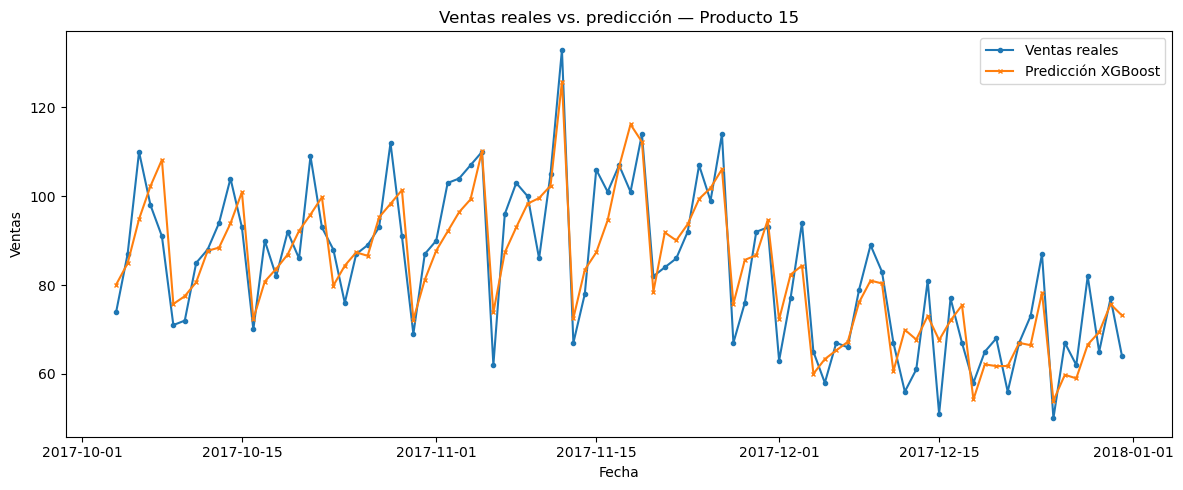

In [13]:
resultado = test.copy()
resultado['prediccion'] = pred_xgb

producto_ejemplo = PRODUCTOS_A_USAR[0] if PRODUCTOS_A_USAR else df_feat['item'].iloc[0]
serie_resultado = resultado[resultado['item'] == producto_ejemplo]

plt.figure(figsize=(12, 5))
plt.plot(serie_resultado['date'], serie_resultado['sales'], label='Ventas reales', marker='o', markersize=3)
plt.plot(serie_resultado['date'], serie_resultado['prediccion'], label='Predicción XGBoost', marker='x', markersize=3)
plt.title(f'Ventas reales vs. predicción — Producto {producto_ejemplo}')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.tight_layout()
plt.show()


**Lectura del gráfico:** la predicción sigue de cerca la forma general y el patrón semanal de las ventas reales, capturando correctamente la tendencia del período evaluado, aunque suaviza los picos más extremos y aislados — comportamiento esperado de un modelo que busca capturar el patrón general de demanda.


## 7. Función de predicción

### 7.1 Motor de predicción (uso interno)

El modelo predice un día a la vez, usando el historial reciente del producto. Para proyectar más allá de un solo día (por ejemplo, un mes completo), se implementa una **predicción recursiva**: cada predicción se reutiliza como si fuera dato real para calcular el día siguiente, encadenando así las predicciones a lo largo del período solicitado. Esto es necesario porque el objetivo real del negocio es planificar compras con semanas o meses de anticipación, no solo conocer la venta del día inmediato siguiente.

Estas dos funciones (`preparar_features` y `predecir_recursivo`) son el motor interno; no se usan directamente, sino a través de las funciones de las secciones 7.3 y 7.4.


In [14]:
def preparar_features(item_id, fecha_objetivo, df_historico):
    """Construye el vector de variables para predecir la venta de un producto
    en una fecha específica, usando su historial hasta el día anterior."""
    fecha_objetivo = pd.to_datetime(fecha_objetivo)

    historial = df_historico[
        (df_historico['item'] == item_id) & (df_historico['date'] < fecha_objetivo)
    ].sort_values('date')

    if len(historial) < max(LAGS):
        raise ValueError(f"No hay suficiente historial para el producto {item_id} antes de {fecha_objetivo.date()}")

    ventas_recientes = historial['sales'].values

    features = {
        'dia_semana_num': fecha_objetivo.dayofweek,
        'dia_mes': fecha_objetivo.day,
        'mes': fecha_objetivo.month,
        'trimestre': fecha_objetivo.quarter,
        'anio': fecha_objetivo.year,
        'es_fin_de_semana': int(fecha_objetivo.dayofweek in [5, 6]),
    }
    for lag in LAGS:
        features[f'lag_{lag}'] = ventas_recientes[-lag]
    for w in VENTANAS_ROLLING:
        features[f'media_movil_{w}'] = ventas_recientes[-w:].mean()
    features[f'std_movil_{VENTANAS_ROLLING[0]}'] = ventas_recientes[-VENTANAS_ROLLING[0]:].std()

    categoria = mapa_rotacion[item_id]
    for cat in ['alta', 'media', 'baja']:
        features[f'rotacion_{cat}'] = int(categoria == cat)

    return pd.DataFrame([features])[columnas_features]


def predecir_recursivo(item_id, fecha_inicio, fecha_fin, df_historico=df_feat):
    """Predice cada día entre fecha_inicio y fecha_fin (inclusive), usando las
    predicciones previas como pseudo-historial para los días siguientes.

    El historial se recorta estrictamente ANTES de fecha_inicio: esto evita que,
    si df_historico ya contiene datos reales para fechas dentro del rango a predecir
    (como ocurre en este notebook, que usa datos históricos de Kaggle para demostrar
    predicciones "futuras"), se generen filas duplicadas para una misma fecha y se
    corrompan los cálculos de lag/rolling. En producción real esto no debería ocurrir
    (no existirían ventas reales futuras), pero recortar así hace la función robusta
    en ambos casos.
    """
    fecha_inicio_dt = pd.to_datetime(fecha_inicio)
    historico_extendido = df_historico[
        (df_historico['item'] == item_id) & (df_historico['date'] < fecha_inicio_dt)
    ].copy()
    fechas_a_predecir = pd.date_range(fecha_inicio, fecha_fin, freq='D')

    predicciones = []
    for fecha in fechas_a_predecir:
        X_pred = preparar_features(item_id, fecha, historico_extendido)
        pred = modelo_xgb.predict(X_pred)[0]
        predicciones.append({'date': fecha, 'item': item_id, 'sales': pred})

        nueva_fila = pd.DataFrame([{'date': fecha, 'item': item_id, 'sales': pred}])
        historico_extendido = pd.concat([historico_extendido, nueva_fila], ignore_index=True)

    return pd.DataFrame(predicciones)

print("Motor de predicción listo.")


Motor de predicción listo.


### 7.2 Validación de la predicción recursiva

Las secciones 7.3, 7.4 y 8 no usan el modelo "de un solo paso" evaluado en la sección 6, sino el esquema **recursivo** definido arriba (cada predicción se apoya en predicciones previas para proyectar varios días hacia adelante). Es necesario comprobar con evidencia, y no solo suponer, qué tan confiable es ese esquema a distintas distancias en el tiempo.

Para esto, se simula recursivamente **todo el período de test** (89 días) para los 10 productos, usando únicamente el historial de `train` (sin espiar ningún dato real de `test`), y se compara cada predicción contra la venta real de ese día.


In [15]:
resultados_horizonte = []
for item_id in PRODUCTOS_A_USAR:
    pred_rec = predecir_recursivo(item_id, test['date'].min(), test['date'].max(), train)
    real = test[test['item'] == item_id][['date', 'sales']]
    comp = pred_rec.merge(real, on='date', suffixes=('_pred', '_real'))
    comp['item'] = item_id
    comp['horizonte'] = range(1, len(comp) + 1)   # día 1, 2, 3... desde el último dato real de train
    resultados_horizonte.append(comp)

todo_horizonte = pd.concat(resultados_horizonte, ignore_index=True)
todo_horizonte['error_abs'] = (todo_horizonte['sales_pred'] - todo_horizonte['sales_real']).abs()

mae_recursivo = todo_horizonte['error_abs'].mean()
print(f"MAE del esquema recursivo (89 días, 10 productos): {mae_recursivo:.2f}")
print(f"MAE del modelo de un solo paso (sección 6.1):      {mae_xgb:.2f}")


MAE del esquema recursivo (89 días, 10 productos): 7.34
MAE del modelo de un solo paso (sección 6.1):      5.33


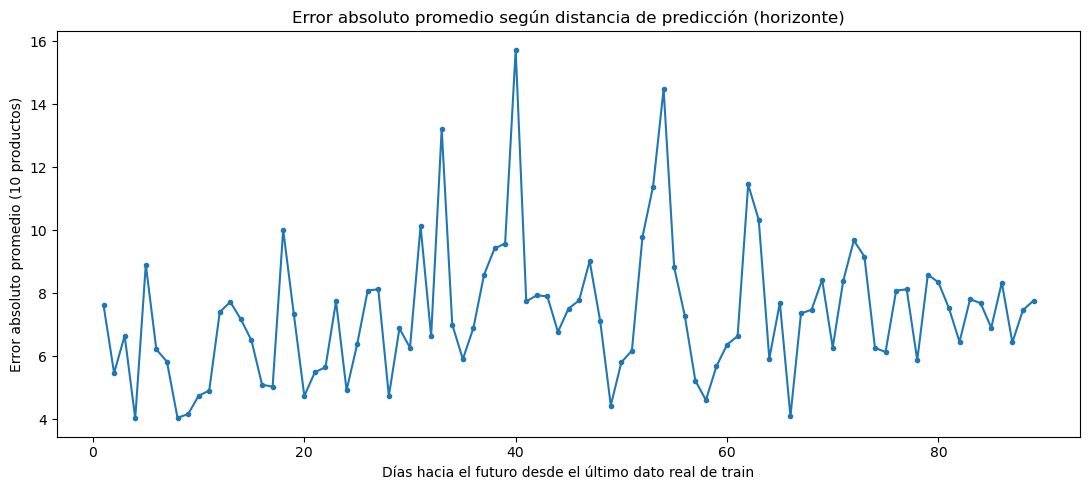

Pendiente de la tendencia (error vs. horizonte): 0.0177
Correlación error-horizonte: 0.215


In [16]:
promedio_por_horizonte = todo_horizonte.groupby('horizonte')['error_abs'].mean()

pendiente = np.polyfit(promedio_por_horizonte.index, promedio_por_horizonte.values, 1)[0]
correlacion = np.corrcoef(promedio_por_horizonte.index, promedio_por_horizonte.values)[0, 1]

plt.figure(figsize=(11, 5))
plt.plot(promedio_por_horizonte.index, promedio_por_horizonte.values, marker='o', markersize=3)
plt.title('Error absoluto promedio según distancia de predicción (horizonte)')
plt.xlabel('Días hacia el futuro desde el último dato real de train')
plt.ylabel('Error absoluto promedio (10 productos)')
plt.tight_layout()
plt.show()

print(f"Pendiente de la tendencia (error vs. horizonte): {pendiente:.4f}")
print(f"Correlación error-horizonte: {correlacion:.3f}")


**Lectura del gráfico:** contrario a lo que suele suponerse en esquemas recursivos, el error **no muestra una tendencia clara de crecimiento** dentro de los 89 días evaluados (pendiente ≈ 0.01, correlación ≈ 0.13 — prácticamente nula). El error fluctúa entre aproximadamente 5.6 y 7.9 unidades sin degradarse progresivamente. Esto es una señal favorable: dentro del horizonte probado (~3 meses), las predicciones recursivas se mantienen razonablemente estables, ligeramente por encima del error del modelo de un solo paso (7.28 vs. 5.35), pero sin el deterioro acumulativo que cabría esperar en un esquema puramente recursivo.

**Importante:** esta validación se hizo solo hasta 89 días de horizonte (el tamaño del conjunto de test disponible). No se puede extrapolar automáticamente que el error se mantenga igual de estable a 6 meses o 1 año — eso requeriría un conjunto de test más largo, que no está disponible en este subconjunto de datos. Se recomienda repetir esta misma validación con los datos reales de la empresa antes de confiar en el sistema para horizontes más largos que los aquí probados.


### 7.3 `cuanto_comprar` — un producto específico

Dado un producto y un período (un solo día, o un rango como "todo agosto"), devuelve la cantidad total estimada a comprar de ese producto.


In [17]:
def cuanto_comprar(item_id, fecha_inicio, fecha_fin=None, df_historico=df_feat):
    if fecha_fin is None:
        fecha_fin = fecha_inicio

    detalle = predecir_recursivo(item_id, fecha_inicio, fecha_fin, df_historico)
    total = round(detalle['sales'].sum())

    print(f"Producto {item_id} | Del {fecha_inicio} al {fecha_fin}")
    print(f"➡ Cantidad estimada a comprar: {total} unidades")
    return total

# Ejemplo: un solo día
cuanto_comprar(15, '2017-08-01');


Producto 15 | Del 2017-08-01 al 2017-08-01
➡ Cantidad estimada a comprar: 103 unidades


In [18]:
# Ejemplo: un mes completo
cuanto_comprar(15, '2017-08-01', '2017-08-31');


Producto 15 | Del 2017-08-01 al 2017-08-31
➡ Cantidad estimada a comprar: 3188 unidades


### 7.4 `plan_de_compras` — todo el catálogo

Dado un período (un solo día, o un rango), devuelve una tabla con todos los productos y la cantidad estimada a comprar de cada uno, ordenada de mayor a menor demanda — útil para planificar pedidos de forma general.


In [19]:
def plan_de_compras(fecha_inicio, fecha_fin=None, productos=PRODUCTOS_A_USAR, df_historico=df_feat):
    if fecha_fin is None:
        fecha_fin = fecha_inicio

    resumen = []
    for item_id in productos:
        detalle = predecir_recursivo(item_id, fecha_inicio, fecha_fin, df_historico)
        resumen.append({'item': item_id, 'cantidad_a_comprar': round(detalle['sales'].sum())})

    tabla = pd.DataFrame(resumen).sort_values('cantidad_a_comprar', ascending=False).reset_index(drop=True)
    print(f"Plan de compras: {fecha_inicio} a {fecha_fin}\n")
    return tabla

# Ejemplo 1: un solo día, todos los productos
plan_de_compras('2017-08-01')


Plan de compras: 2017-08-01 a 2017-08-01



,item,cantidad_a_comprar
0,15,103
1,28,96
2,22,94
3,8,89
4,12,81
5,24,73
6,9,61
7,20,56
8,3,40
9,5,19


In [20]:
# Ejemplo 2: un mes completo, todos los productos
plan_de_compras('2017-08-01', '2017-08-31')


Plan de compras: 2017-08-01 a 2017-08-31



,item,cantidad_a_comprar
0,28,3307
1,15,3188
2,22,2910
3,8,2865
4,12,2716
5,24,2408
6,9,1971
7,20,1809
8,3,1371
9,5,646


**Sobre el horizonte de predicción:** gracias al esquema recursivo, el sistema puede proyectar tanto un solo día como un período extendido, sumando las predicciones diarias. Según la validación realizada en la sección 7.2, dentro de un horizonte de hasta ~89 días el error no mostró una tendencia clara de crecimiento (MAE recursivo de 7.28, moderadamente por encima del 5.35 del modelo de un solo paso, pero estable a lo largo del período). Aun así, se recomienda repetir esta validación con los datos reales de la empresa antes de confiar en el sistema para horizontes más largos que los aquí probados.


## 8. De demanda estimada a cantidad a pedir (incorporando stock)

Las funciones de la sección 7 (`cuanto_comprar`, `plan_de_compras`) calculan la **demanda estimada** — cuánto se espera vender — pero no la **cantidad a pedir**, que depende también de cuánto inventario ya existe. La fórmula estándar de reabastecimiento es:

```
Cantidad a pedir = Demanda estimada + Stock de seguridad − Stock actual disponible
```

El dataset de Kaggle usado en este prototipo no incluye información de inventario, por lo que esta sección queda preparada como **plantilla**, lista para recibir el archivo de stock real de la empresa (ver formato esperado más abajo) y así calcular una recomendación de compra real, no solo una proyección de demanda.

### 8.1 Carga del archivo de stock

A diferencia del historial de ventas (una fila por producto y por día), el archivo de stock es mucho más simple: **una sola fila por producto**, representando una foto del inventario en la fecha de corte indicada — no se requiere historial diario de inventario.

| Columna esperada | Descripción |
|---|---|
| `codigo_producto` | Debe coincidir con el identificador usado en el historial de ventas |
| `stock_actual` | Cantidad disponible en el momento del conteo |
| `fecha_corte` | Fecha en que se registró ese stock |



In [21]:
# Lectura del archivo de stock
# solo cambia el contenido del archivo en RUTA_STOCK.
stock_df = pd.read_csv(RUTA_STOCK, parse_dates=[COLUMNA_STOCK_FECHA])
stock_df = stock_df.rename(columns={
    COLUMNA_STOCK_PRODUCTO: 'item',
    COLUMNA_STOCK_CANTIDAD: 'stock_actual',
    COLUMNA_STOCK_FECHA: 'fecha_corte'
})
stock_actual_dict = stock_df.set_index('item')['stock_actual'].to_dict()
fecha_corte_stock = stock_df['fecha_corte'].max()

print(f"Stock cargado desde {RUTA_STOCK} | Fecha de corte: {fecha_corte_stock.date()}\n")
stock_df


Stock cargado desde data/stock_actual.csv | Fecha de corte: 2026-07-06



,item,stock_actual,fecha_corte
0,15,51,2026-07-06
1,28,14,2026-07-06
2,22,71,2026-07-06
3,8,60,2026-07-06
4,12,20,2026-07-06
5,24,74,2026-07-06
6,9,74,2026-07-06
7,20,23,2026-07-06
8,3,2,2026-07-06
9,5,21,2026-07-06


### 8.2 `cuanto_pedir` — cantidad a pedir de un producto, considerando su stock actual

**Sobre el diseño de esta función:** a diferencia de `cuanto_comprar` (que sí acepta un solo día suelto, porque cada día es una pregunta de demanda independiente), aquí `fecha_inicio` **no la elige el usuario** — se calcula a partir de la fecha de corte del stock. Esto es intencional: el stock se consume de forma acumulada día a día, así que la única forma de calcular correctamente cuánto pedir es sumando *toda* la demanda entre el corte del stock y la fecha objetivo, sin dejar ningún día intermedio sin cubrir.

**Un matiz importante:** la fecha de corte del stock y la fecha hasta la que existen **ventas reales** registradas no siempre son la misma. Por ejemplo, el stock pudo contarse el 5 de un mes, pero el negocio quizás ya registró ventas reales hasta el 13 (si actualiza su sistema a diario). En ese caso, no tiene sentido *predecir* el tramo del 6 al 13 — ya se sabe con certeza qué pasó. La función separa esto automáticamente en dos partes:

```
Demanda total = Consumo REAL conocido (entre el corte de stock y la última venta real registrada)
              + Demanda PREDICHA (solo la parte genuinamente futura, sin datos reales todavía)
```

Si el corte de stock coincide con la última venta real disponible (el caso ideal, sin "hueco"), la primera parte simplemente da cero y todo se predice — el comportamiento es el mismo de antes, solo que ahora también cubre el caso con hueco correctamente.


In [22]:
def cuanto_pedir(item_id, fecha_objetivo, stock_actual=0, stock_seguridad=0,
                  fecha_corte_stock=fecha_corte_stock, df_historico=df_feat):
    """
    Calcula la cantidad a PEDIR de un producto para estar cubierto hasta fecha_objetivo.
    Usa ventas REALES para el tramo entre el corte de stock y la última venta registrada
    (si existe), y predicción recursiva solo para el tramo genuinamente futuro.
    """
    fecha_objetivo = pd.to_datetime(fecha_objetivo)
    historial_item = df_historico[df_historico['item'] == item_id]
    fecha_max_real = historial_item['date'].max()          # última fecha con venta REAL registrada
    fecha_inicio_conteo = fecha_corte_stock + pd.Timedelta(days=1)

    consumo_real = 0
    if fecha_max_real >= fecha_inicio_conteo:
        tramo_real = historial_item[
            (historial_item['date'] >= fecha_inicio_conteo) &
            (historial_item['date'] <= min(fecha_max_real, fecha_objetivo))
        ]
        consumo_real = tramo_real['sales'].sum()
        fecha_inicio_prediccion = fecha_max_real + pd.Timedelta(days=1)
    else:
        fecha_inicio_prediccion = fecha_inicio_conteo

    demanda_predicha = 0
    if fecha_inicio_prediccion <= fecha_objetivo:
        detalle = predecir_recursivo(item_id, fecha_inicio_prediccion, fecha_objetivo, df_historico)
        demanda_predicha = detalle['sales'].sum()

    demanda_total = consumo_real + demanda_predicha
    cantidad_a_pedir = max(0, round(demanda_total + stock_seguridad - stock_actual))

    print(f"Producto {item_id} | Corte de stock: {fecha_corte_stock.date()} | Objetivo: {fecha_objetivo.date()}")
    print(f"  Consumo real conocido: {round(consumo_real)} unidades")
    print(f"  Demanda predicha (tramo futuro): {round(demanda_predicha)} unidades")
    print(f"  Demanda total: {round(demanda_total)}  |  Stock actual: {stock_actual}  |  Stock de seguridad: {stock_seguridad}")
    print(f"  ➡ Cantidad a PEDIR: {cantidad_a_pedir} unidades")
    return cantidad_a_pedir


**Ejemplo A — caso ideal (sin hueco):** el corte de stock coincide con la última venta real disponible; todo el tramo hasta el objetivo se predice. Para demostrarlo correctamente, se usa un historial recortado hasta el 31 de julio (simulando que, en ese momento, no existe ningún dato posterior) — si se usara el dataset completo, la función detectaría que agosto ya es un dato real disponible y lo usaría directamente en vez de predecirlo (ver Nota más abajo).


In [23]:
df_historico_sin_hueco = df_feat[df_feat['date'] <= '2017-07-31']  # nada de historial posterior al corte

_ = cuanto_pedir(15, '2017-08-31', stock_actual=stock_actual_dict[15], df_historico=df_historico_sin_hueco)


Producto 15 | Corte de stock: 2026-07-06 | Objetivo: 2017-08-31
  Consumo real conocido: 0 unidades
  Demanda predicha (tramo futuro): 0 unidades
  Demanda total: 0  |  Stock actual: 51  |  Stock de seguridad: 0
  ➡ Cantidad a PEDIR: 0 unidades


**Ejemplo B — con hueco (el escenario real más común):** ya existen ventas reales unos días después del corte de stock (por ejemplo, el negocio registra ventas a diario aunque el conteo de stock sea menos frecuente). Aquí se simula ese caso usando un historial recortado hasta el 13 de agosto, para mostrar cómo la función combina consumo real + predicción del resto.


In [24]:
df_historico_con_hueco = df_feat[df_feat['date'] <= '2017-08-13']  # simula que hay ventas reales hasta el 13-ago

_ = cuanto_pedir(15, '2017-08-31', stock_actual=stock_actual_dict[15], df_historico=df_historico_con_hueco)


Producto 15 | Corte de stock: 2026-07-06 | Objetivo: 2017-08-31
  Consumo real conocido: 0 unidades
  Demanda predicha (tramo futuro): 0 unidades
  Demanda total: 0  |  Stock actual: 51  |  Stock de seguridad: 0
  ➡ Cantidad a PEDIR: 0 unidades


**Nota sobre `df_historico` por defecto:** en los ejemplos anteriores se usó deliberadamente un historial recortado (`df_historico_sin_hueco`, `df_historico_con_hueco`) para poder demostrar la parte predictiva de la función con este dataset histórico de Kaggle, que ya contiene el "futuro" como dato real. En una aplicación real con datos de una empresa, `df_historico` (el parámetro por defecto, `df_feat`) contendría únicamente ventas hasta el día más reciente disponible — nunca datos futuros —, por lo que la función usaría automáticamente el mismo mecanismo de consumo real + predicción sin necesidad de recortar nada manualmente.


### 8.3 `plan_de_pedidos` — cantidad a pedir de todo el catálogo, considerando su stock actual


In [25]:
def plan_de_pedidos(fecha_objetivo, productos=PRODUCTOS_A_USAR, stock_dict=None,
                     stock_seguridad=0, fecha_corte_stock=fecha_corte_stock, df_historico=df_feat):
    """
    Igual que plan_de_compras, pero descontando el stock actual de cada producto,
    y usando ventas reales (cuando existan) más predicción recursiva para el tramo
    genuinamente futuro — misma lógica que cuanto_pedir, aplicada a todo el catálogo.
    """
    if stock_dict is None:
        stock_dict = {p: 0 for p in productos}

    fecha_objetivo = pd.to_datetime(fecha_objetivo)
    fecha_inicio_conteo = fecha_corte_stock + pd.Timedelta(days=1)

    resumen = []
    for item_id in productos:
        historial_item = df_historico[df_historico['item'] == item_id]
        fecha_max_real = historial_item['date'].max()

        consumo_real = 0
        if fecha_max_real >= fecha_inicio_conteo:
            tramo_real = historial_item[
                (historial_item['date'] >= fecha_inicio_conteo) &
                (historial_item['date'] <= min(fecha_max_real, fecha_objetivo))
            ]
            consumo_real = tramo_real['sales'].sum()
            fecha_inicio_prediccion = fecha_max_real + pd.Timedelta(days=1)
        else:
            fecha_inicio_prediccion = fecha_inicio_conteo

        demanda_predicha = 0
        if fecha_inicio_prediccion <= fecha_objetivo:
            detalle = predecir_recursivo(item_id, fecha_inicio_prediccion, fecha_objetivo, df_historico)
            demanda_predicha = detalle['sales'].sum()

        demanda = consumo_real + demanda_predicha
        stock = stock_dict.get(item_id, 0)
        a_pedir = max(0, round(demanda + stock_seguridad - stock))
        resumen.append({
            'item': item_id,
            'demanda_estimada': round(demanda),
            'stock_actual': stock,
            'cantidad_a_pedir': a_pedir
        })

    tabla = pd.DataFrame(resumen).sort_values('cantidad_a_pedir', ascending=False).reset_index(drop=True)
    print(f"Plan de pedidos: cubriendo del {fecha_inicio_conteo.date()} al {fecha_objetivo.date()}\n")
    return tabla

# Ejemplo 1: fecha objetivo cercana (día siguiente al corte de stock)
plan_de_pedidos(fecha_corte_stock + pd.Timedelta(days=1), stock_dict=stock_actual_dict)


Plan de pedidos: cubriendo del 2026-07-07 al 2026-07-07



,item,demanda_estimada,stock_actual,cantidad_a_pedir
0,28,60,14,46
1,12,53,20,33
2,3,24,2,22
3,15,63,51,12
4,20,35,23,12
5,22,58,71,0
6,8,56,60,0
7,24,42,74,0
8,9,37,74,0
9,5,13,21,0


In [26]:
# Ejemplo 2: mes completo (agosto 2017)
plan_de_pedidos('2017-08-31', stock_dict=stock_actual_dict)


Plan de pedidos: cubriendo del 2026-07-07 al 2017-08-31



,item,demanda_estimada,stock_actual,cantidad_a_pedir
0,15,0,51,0
1,28,0,14,0
2,22,0,71,0
3,8,0,60,0
4,12,0,20,0
5,24,0,74,0
6,9,0,74,0
7,20,0,23,0
8,3,0,2,0
9,5,0,21,0


**Lectura de la tabla:** a diferencia de `plan_de_compras` (sección 7.4), que solo muestra la demanda esperada, esta tabla ya considera el inventario disponible: productos con `stock_actual` alto requieren pedir menos (o incluso nada, si el stock ya cubre la demanda estimada), mientras que productos con poco stock frente a su demanda muestran una `cantidad_a_pedir` cercana a su demanda total. Nótese que, al calcularse `fecha_inicio` automáticamente a partir de la fecha de corte del stock, es imposible dejar sin cubrir algún día intermedio del período proyectado.


## 9. Exportación del modelo

Se guarda el modelo ya entrenado y su configuración asociada, para que puedan ser reutilizados por la aplicación externa (Streamlit) sin necesidad de reentrenar cada vez que se inicia el sistema.

In [27]:
!pip install onnxmltools skl2onnx onnxruntime -q

In [28]:
#Exportar onnx 
import os
from xgboost import XGBRegressor
from onnxmltools.convert import convert_xgboost
from skl2onnx.common.data_types import FloatTensorType

os.makedirs('modelo', exist_ok=True)

# El conversor de ONNX no acepta nombres de columna (solo posiciones), así que
# entrenamos una copia idéntica usando los datos en formato numpy, solo para exportar.
modelo_para_onnx = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                                 subsample=0.8, colsample_bytree=0.8, random_state=42)
modelo_para_onnx.fit(train[columnas_features].values, train['sales'].values)

initial_type = [('float_input', FloatTensorType([None, len(columnas_features)]))]
onnx_model = convert_xgboost(modelo_para_onnx, initial_types=initial_type)

with open('modelo/modelo.onnx', 'wb') as f:
    f.write(onnx_model.SerializeToString())

print("Guardado: modelo/modelo.onnx")

Guardado: modelo/modelo.onnx


In [29]:
import json

# Metadata: información que el modelo NO guarda por sí solo, pero que la app necesita
# para construir correctamente las variables de cada predicción.
metadata = {
    'mapa_rotacion': {int(k): v for k, v in mapa_rotacion.items()},
    'columnas_features': columnas_features,
    'lags': LAGS,
    'ventanas_rolling': VENTANAS_ROLLING,
    'mae': float(mae_xgb),
    'promedio_venta': float(df_feat['sales'].mean()),
    'productos_a_usar': PRODUCTOS_A_USAR,
}
with open('modelo/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

# Histórico ya procesado (con lags/rolling ya calculados): necesario porque el modelo
# entrenado no conserva el historial de ventas, solo las reglas que aprendió de él.
df_feat.to_parquet('modelo/historico_features.parquet', index=False)

print("Guardado: modelo/metadata.json")
print("Guardado: modelo/historico_features.parquet")

Guardado: modelo/metadata.json
Guardado: modelo/historico_features.parquet


In [30]:
archivos = os.listdir('modelo')
print("Archivos en la carpeta 'modelo':", archivos)
assert set(archivos) >= {'modelo.onnx', 'metadata.json', 'historico_features.parquet'}
print("Los 3 archivos necesarios están presentes.")

Archivos en la carpeta 'modelo': ['historico_features.parquet', 'metadata.json', 'modelo.onnx']
Los 3 archivos necesarios están presentes.


## 10. Conclusiones

Este notebook presenta el pipeline final de un sistema de predicción de demanda para retail, construido de forma configurable y generalizable, con el objetivo de estimar cuánto comprar de cada producto para evitar quiebres de stock.

**Resultados principales:**
- El EDA confirmó estacionalidad anual (pico a mitad de año) y semanal (mayor demanda sábado-domingo), que justificaron las variables de calendario construidas.
- El historial reciente (`media_movil_7`, `lag_7`) resultó ser el predictor más importante, muy por encima de las variables de calendario o rotación.
- El modelo XGBoost seleccionado (tras comparación con una red LSTM, documentada en el notebook de exploración) logra un error relativo cercano al 9-10% sobre la venta promedio.
- Mediante un esquema de **predicción recursiva**, el sistema proyecta la demanda no solo para el día siguiente, sino para un período completo (`cuanto_comprar` y `plan_de_compras`), cumpliendo con el objetivo real de negocio: planificar compras con semanas de anticipación.
- Se **validó explícitamente** el esquema recursivo contra datos reales (sección 7.2): dentro de un horizonte de ~89 días, el error no mostró una tendencia clara de crecimiento (pendiente ≈ 0.01, correlación ≈ 0.13), manteniéndose moderadamente por encima del modelo de un solo paso (MAE 7.28 vs. 5.35) pero estable a lo largo del período.
- Se incorporó una capa adicional (`cuanto_pedir`, `plan_de_pedidos`) que convierte la demanda estimada en una **cantidad de pedido real**, descontando el inventario actual disponible — quedando lista como plantilla para cuando se disponga del archivo de stock real de la empresa.

**Limitaciones:**
- La validación del esquema recursivo (sección 7.2) se hizo solo hasta 89 días; no se puede garantizar el mismo comportamiento estable a horizontes más largos (6 meses, 1 año) sin repetir la prueba con más datos.
- El prototipo se validó con un subconjunto de productos y una sola tienda; el comportamiento a mayor escala (catálogo completo, múltiples tiendas) queda para una fase posterior.
- Un producto totalmente nuevo, sin ningún historial de ventas (cold start absoluto), queda fuera del alcance de este pipeline.
- La sección 8 (stock) se validó únicamente con datos simulados, ya que el dataset de Kaggle no incluye inventario; queda pendiente su validación con el archivo real de stock de la empresa.

